In [ ]:
import polars as pl

iedb_II = pl.read_parquet("../../data/iedb_II/triad/iedb_II_triad.conf_af3.parquet")

cresta = pl.read_parquet("../../data/cresta/triad/staged/cresta_triad.conf_af3.parquet")

pdb_v = pl.read_parquet(
    "../../data/pdb/triad/staged/pdb_validation_triad.conf_af3.parquet"
)

In [23]:
import sklearn.metrics as metrics
import matplotlib.pyplot as plt
import numpy as np


def violin_abs_feature(df, featname: str, invert=False):
    """
    Violin plot of |feature| for cognates vs noncognates.
    Annotates:
      - absolute feature threshold T above which no noncognates are found
      - # and % of cognates with |feature| > T
    """
    # Pull data from Polars or Pandas
    if hasattr(df, "select"):  # Polars
        dat = df.select([featname, "cognate"]).to_numpy()
    else:  # Pandas/DataFrame-like
        dat = df[[featname, "cognate"]].to_numpy()

    x = dat[:, 0].astype(float)
    y = dat[:, 1].astype(bool)  # True = cognate

    # Drop NaNs / infs in the feature
    finite = np.isfinite(x)
    x = x[finite]
    y = y[finite]

    x_abs = np.abs(x)
    cog_vals = x_abs[y]
    non_vals = x_abs[~y]

    # Threshold T: "absolute feature value above which no noncognates are found"
    if non_vals.size > 0:
        if invert:
            T = float(np.min(non_vals))
        else:
            T = float(np.max(non_vals))
    else:
        T = np.nan  # no noncognates present; threshold undefined

    # Cognate counts above threshold
    if np.isfinite(T) and cog_vals.size > 0:
        if invert:
            n_cog_above = int(np.sum(cog_vals < T))
        else:
            n_cog_above = int(np.sum(cog_vals > T))
        n_cog_total = int(cog_vals.size)
        pct_cog_above = (n_cog_above / n_cog_total) * 100.0
    else:
        n_cog_above = 0
        n_cog_total = int(cog_vals.size)
        pct_cog_above = np.nan

    fig, ax = plt.subplots(figsize=(6, 6))

    parts = ax.violinplot(
        [non_vals, cog_vals],
        positions=[0, 1],
        showmeans=False,
        showmedians=True,
        widths=0.8,
    )

    # Basic cosmetics
    ax.set_xticks([0, 1], labels=["noncognate", "cognate"])
    ax.set_ylabel(f"{featname}")
    ax.set_title(f"Distribution of {featname}")

    # Horizontal line at T
    if np.isfinite(T):
        ax.axhline(T, linestyle="--", linewidth=1, alpha=0.8)
        ax.text(
            0.02,
            0.98,
            f"Threshold feature value = {T:.3g}\n"
            f"Cognates > T: {n_cog_above}/{n_cog_total}"
            + (f" ({pct_cog_above:.1f}%)" if np.isfinite(pct_cog_above) else ""),
            transform=ax.transAxes,
            va="top",
            ha="left",
            fontsize="small",
            bbox=dict(boxstyle="round,pad=0.3", alpha=0.25),
        )

    # Expand y-limits a bit to show the annotation line clearly
    ymin, ymax = ax.get_ylim()
    if np.isfinite(T):
        ymax = max(ymax, T * 1.05 if T > 0 else 1.0)
    ax.set_ylim(ymin, ymax)

    return fig, ax

(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'Distribution of peptide_tcr_contacts'}, ylabel='peptide_tcr_contacts'>)

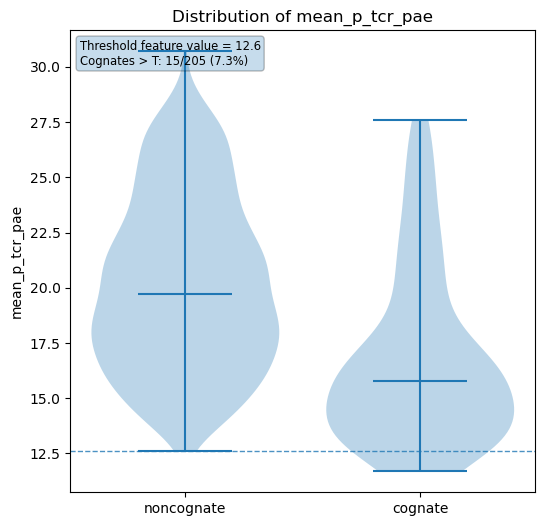

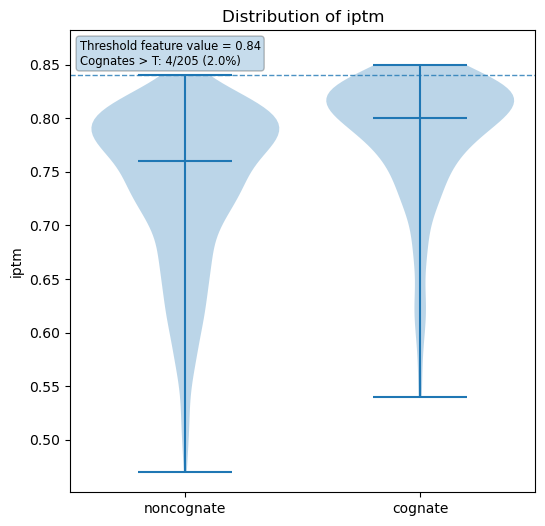

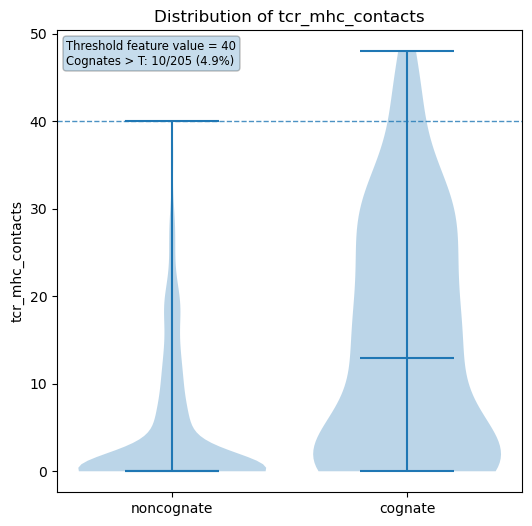

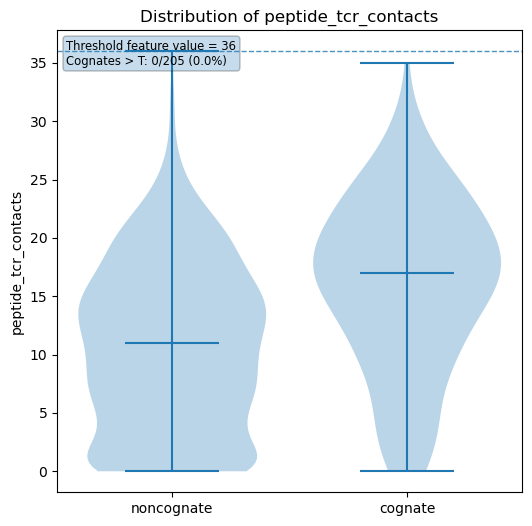

In [38]:
violin_abs_feature(cresta, "mean_p_tcr_pae", invert=True)
violin_abs_feature(cresta, "iptm", invert=False)
violin_abs_feature(cresta, "tcr_mhc_contacts", invert=False)
violin_abs_feature(cresta, "peptide_tcr_contacts", invert=False)

(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'Distribution of mean_p_tcr_pae'}, ylabel='mean_p_tcr_pae'>)

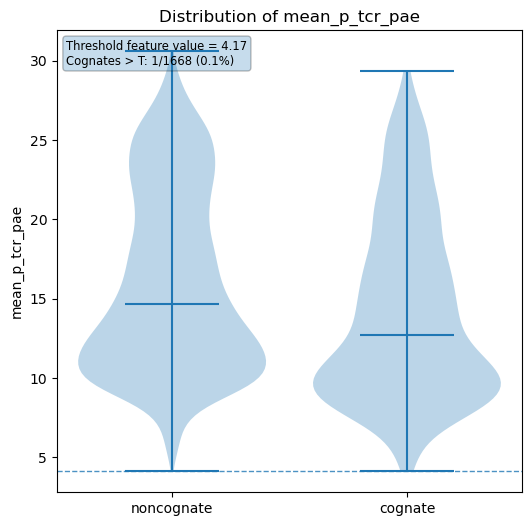

In [35]:
violin_abs_feature(iedb_II, "mean_p_tcr_pae", invert=True)

(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'Distribution of tcr_mhc_contacts'}, ylabel='tcr_mhc_contacts'>)

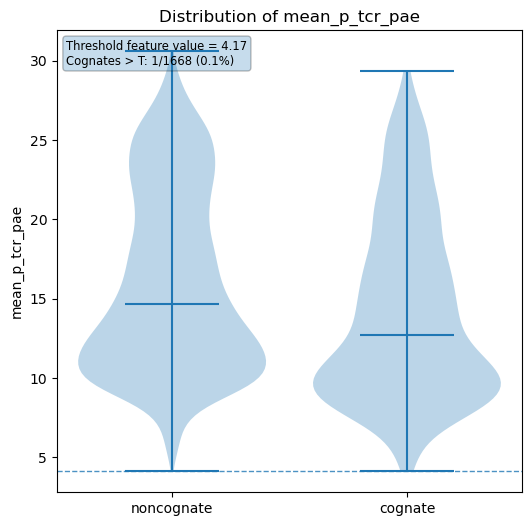

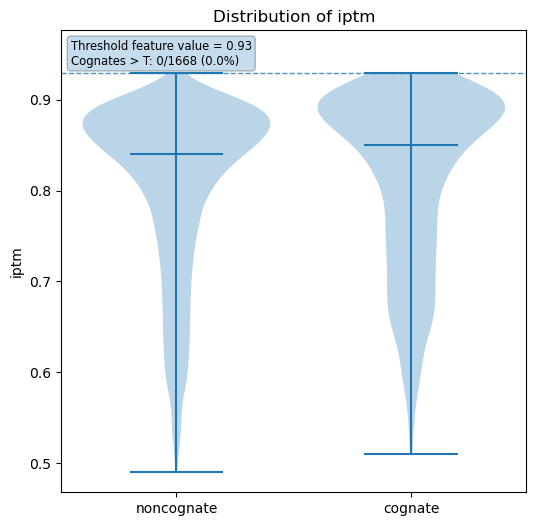

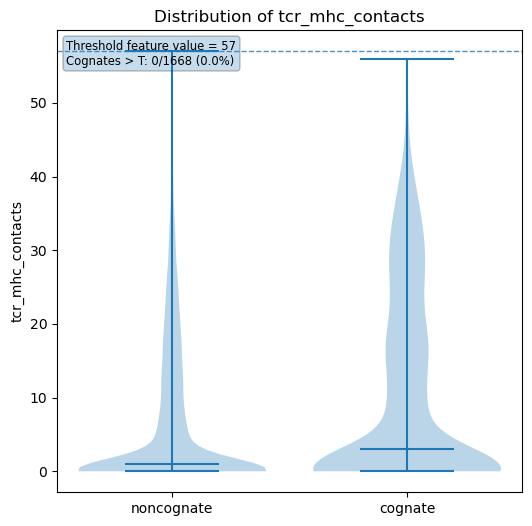

In [36]:
violin_abs_feature(iedb_II, "mean_p_tcr_pae", invert=True)
violin_abs_feature(iedb_II, "iptm", invert=False)
violin_abs_feature(iedb_II, "tcr_mhc_contacts", invert=False)

(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'Distribution of tcr_mhc_contacts'}, ylabel='tcr_mhc_contacts'>)

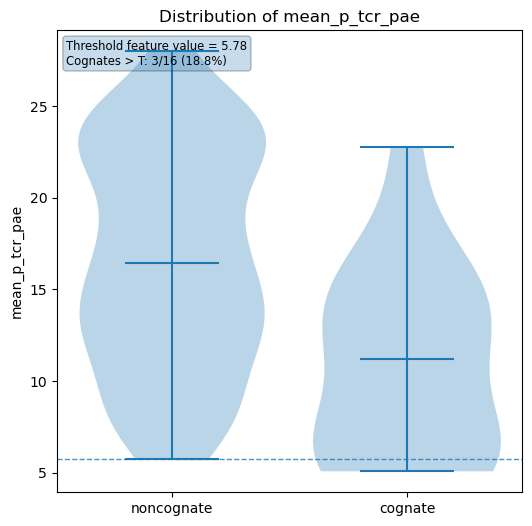

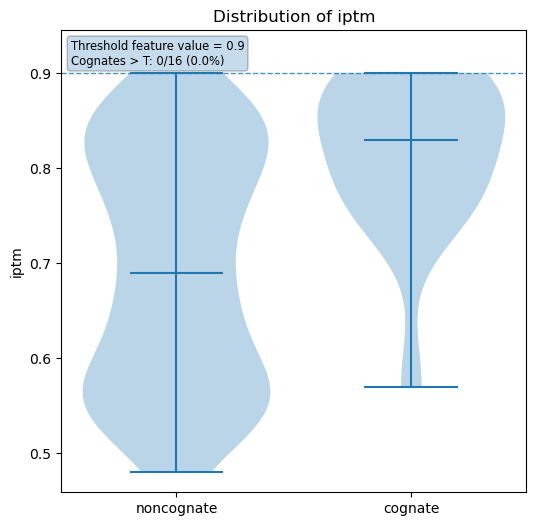

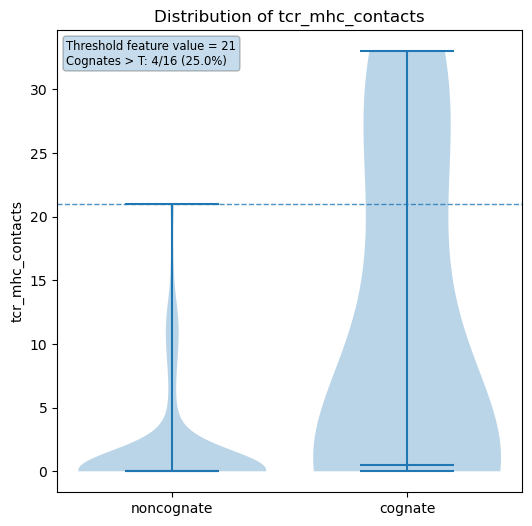

In [37]:
violin_abs_feature(pdb_v, "mean_p_tcr_pae", invert=True)
violin_abs_feature(pdb_v, "iptm", invert=False)
violin_abs_feature(pdb_v, "tcr_mhc_contacts", invert=False)

In [14]:
def plot_correlation(
    x: np.ndarray,
    y: np.ndarray,
    mhc_class: np.ndarray,
    xlabel: str,
    ylabel: str,
    method: str = "pearson",
    title: str | None = None,
    disp_mhc_class: bool = True,
) -> plt.Figure:
    """
    Scatter‐plot x vs y, color points by mhc_class ('I' or 'II'),
    compute and annotate either Pearson or Spearman correlation
    over all points.

    Parameters
    ----------
    x : np.ndarray
        1D array of values for the x‐axis.
    y : np.ndarray
        1D array of values for the y‐axis.
    mhc_class : np.ndarray
        1D array of same length, containing 'I' or 'II' for each point.
    xlabel : str
        Label for the x‐axis.
    ylabel : str
        Label for the y‐axis.
    method : {"pearson", "spearman"}
        Which correlation to compute.
    title : str, optional
        Plot title.

    Returns
    -------
    fig : matplotlib.figure.Figure
        The created figure.
    """
    # validate inputs
    if not (len(x) == len(y) == len(mhc_class)):
        raise ValueError("x, y, and mhc_class must all be the same length")

    # compute overall correlation
    method = method.lower()
    if method == "pearson":
        r, p = stats.pearsonr(x, y)
    elif method == "spearman":
        r, p = stats.spearmanr(x, y)
    else:
        raise ValueError("method must be 'pearson' or 'spearman'")

    fig, ax = plt.subplots()
    # plot by class
    for cls, color in [("I", "tab:blue"), ("II", "tab:orange")]:
        mask = mhc_class == cls

        if disp_mhc_class:
            ax.scatter(
                x[mask],
                y[mask],
                label=f"MHC {cls} (n={mask.sum()})",
                color=color,
                alpha=0.8,
                edgecolors="w",
                linewidth=0.5,
            )
        else:
            ax.scatter(
                x[mask],
                y[mask],
                color=color,
                alpha=0.8,
                edgecolors="w",
                linewidth=0.5,
            )

    # labels and title
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)

    # annotate correlation
    ax.text(
        0.05,
        0.95,
        f"{method.title()} r = {r:.2f}, p = {p:.2g}",
        transform=ax.transAxes,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.6),
    )

    # legend
    ax.legend(loc="upper_right", framealpha=0.7)
    plt.tight_layout()
    return fig